In [5]:
import os
print(os.getcwd())
import sklearn.datasets as datasets
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, ConfusionMatrixDisplay 
from sklearn import tree
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import pandas as pd

/home/ip


In [7]:
iris = datasets.load_iris()

In [8]:
iris_df = pd.DataFrame(iris.data,columns=iris.feature_names)
iris_df['target']=iris.target

In [10]:
iris_df.head()


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [11]:
iris_df.isnull().any()

sepal length (cm)    False
sepal width (cm)     False
petal length (cm)    False
petal width (cm)     False
target               False
dtype: bool

In [8]:
import sklearn.datasets as datasets
import pandas as pd
iris=datasets.load_iris()
iris_df=pd.DataFrame(iris.data,columns=iris.feature_names)
iris_df['target']=iris.target

In [10]:
iris_df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [11]:
iris_df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


In [12]:
iris_df.dtypes

sepal length (cm)    float64
sepal width (cm)     float64
petal length (cm)    float64
petal width (cm)     float64
target                 int64
dtype: object

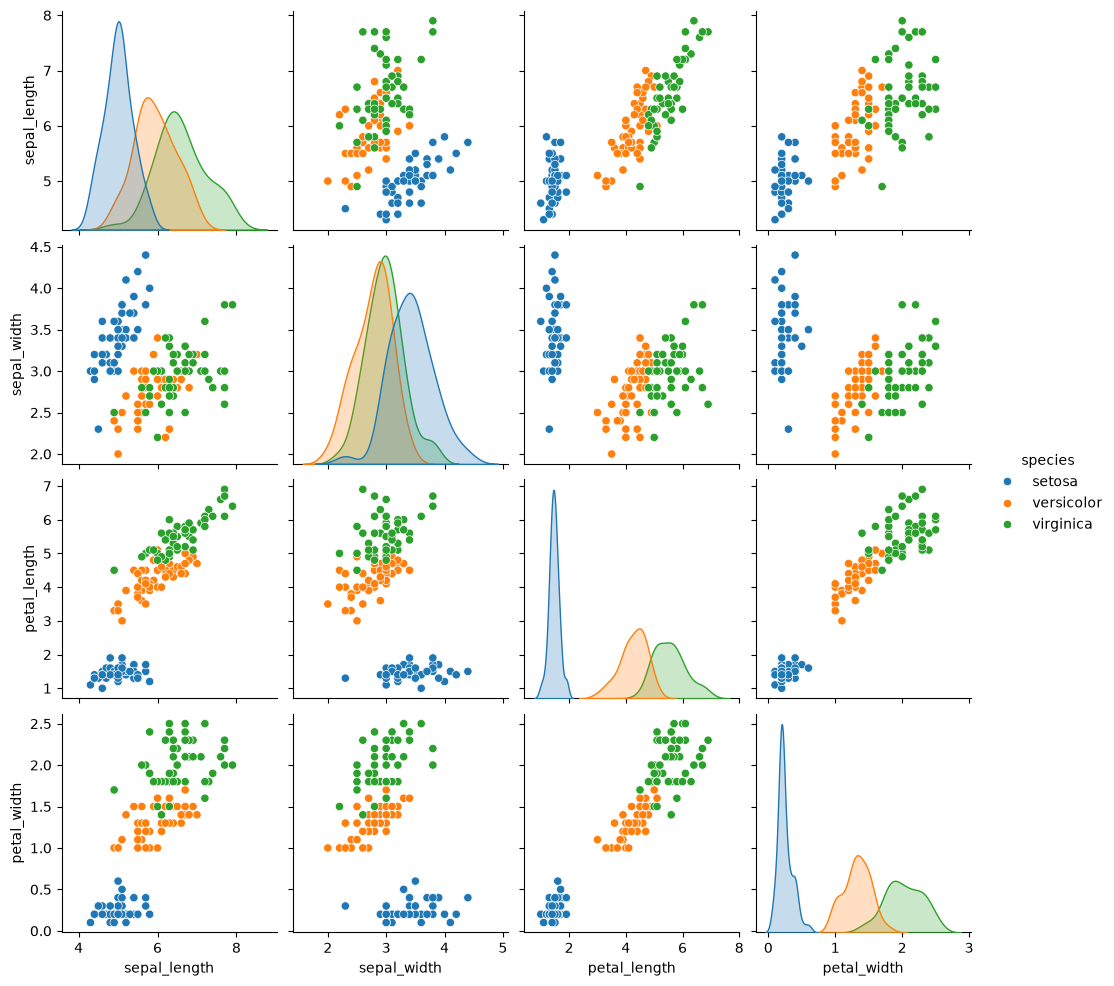

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt
iris_df=sns.load_dataset('iris')
sns.pairplot(iris_df,hue='species')
plt.savefig("exercise2a.png")
plt.show()

In [26]:
from sklearn.model_selection import train_test_split
X=iris_df[['sepal_length','sepal_width','petal_length']].values
y=iris_df['species'].values
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.9,random_state=1)

In [28]:
from sklearn import tree
clf=tree.DecisionTreeClassifier()
clf=clf.fit(X_train,y_train)

In [31]:
from sklearn import tree
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
clf = tree.DecisionTreeClassifier(random_state=0)
clf.fit(X_train, y_train)
prediction = clf.predict(X_test)
print("Accuracy:", accuracy_score(y_test, prediction))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, prediction))
print("\nClassification Report:")
print(classification_report(y_test, prediction))

Accuracy: 1.0

Confusion Matrix:
[[5 0 0]
 [0 6 0]
 [0 0 4]]

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00         5
  versicolor       1.00      1.00      1.00         6
   virginica       1.00      1.00      1.00         4

    accuracy                           1.00        15
   macro avg       1.00      1.00      1.00        15
weighted avg       1.00      1.00      1.00        15



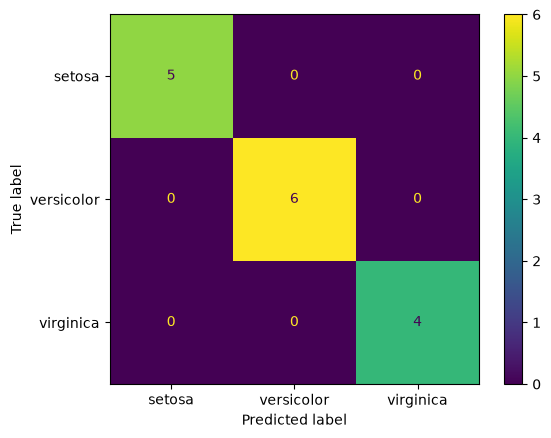

In [37]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
ConfusionMatrixDisplay.from_estimator(clf,X_test,y_test)
plt.savefig("exercise2b.png")
plt.show()

In [38]:
!pip install pydotplus
!pip install graphviz


[notice] A new release of pip is available: 24.2 -> 26.1.2
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 24.2 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [40]:
from io import StringIO
from IPython.display import Image
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier,export_graphviz
import pydotplus

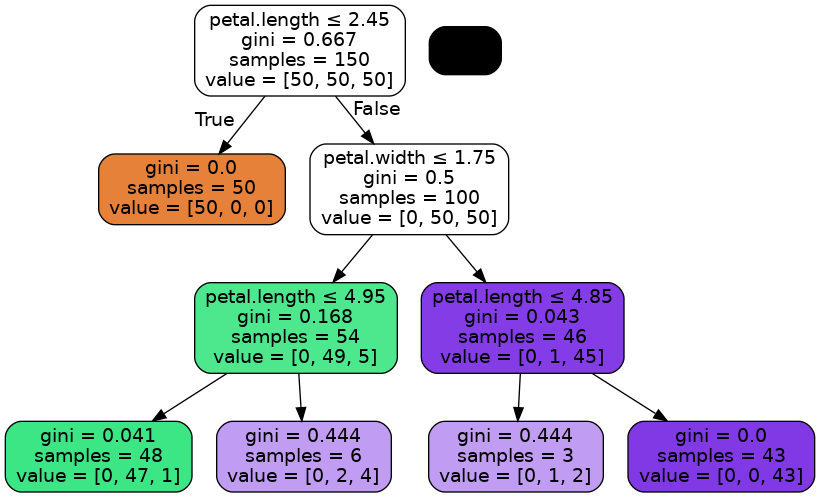

In [41]:
iris=load_iris()
X=iris.data
y=iris.target
clf=DecisionTreeClassifier(max_depth=3,random_state=42)
clf.fit(X,y)
dot_data=StringIO()
export_graphviz(clf,out_file=dot_data,feature_names=['sepal.length','sepal.width','petal.length','petal.width'],filled=True,rounded=True,special_characters=True)
graph=pydotplus.graph_from_dot_data(dot_data.getvalue())
graph.write_png("exercise2c.png")
Image(graph.create_png())

In [43]:
SepalLengthCm = 4.8
SepalWidthCm = 2.9
PetalLengthCm = 1.3
PetalWidthCm = 0.2
x = [[SepalLengthCm, SepalWidthCm, PetalLengthCm, PetalWidthCm]]
res = clf.predict(x)
class_mapping = {
    0: 'setosa',
    1: 'versicolor',
    2: 'virginica'
}
predicted_class = class_mapping[res[0]]
print("The class predicted is -->", predicted_class)

The class predicted is --> setosa
